# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


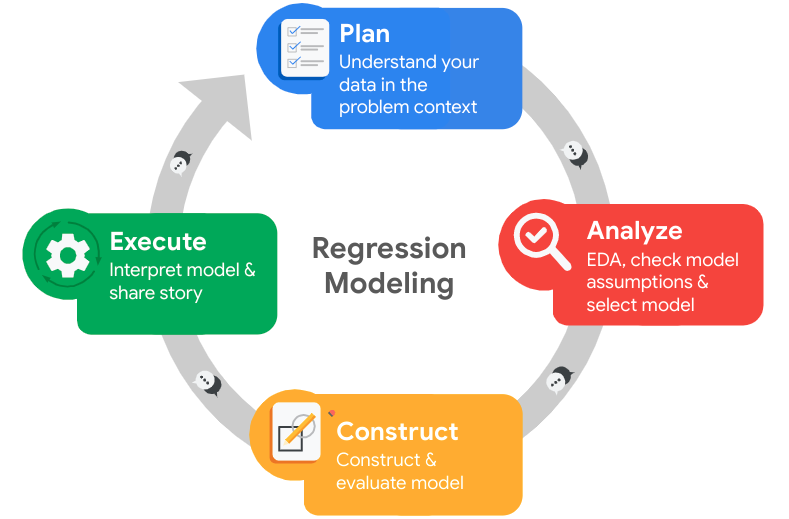

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




1. Who are your stakeholders for this project?
The primary stakeholders are the Human Resources (HR) department and the Senior Executive Leadership team. HR is crucial for developing and implementing targeted retention strategies to keep high-skill talent in a highly competitive market. Executive Leadership is equally critical, as their approval is required for data access, strategic alignment, and navigating the sensitive nature of employee data.
2. What are you trying to solve or accomplish?
The objective is to develop a proactive, predictive machine learning model that identifies high-value employees who are at risk of leaving the company. By transitioning from a reactive to a predictive retention approach, Salifort Motors can strategically intervene, foster stronger relationships with key talent, and prevent costly turnover before it actually occurs.
3. What are your initial observations when you explore the data?
The dataset is structurally robust and relatively clean, requiring minimal foundational intervention. There are no missing values, and the identified duplicates were easily resolved. The outliers observed in the time_spend_company variable represent a logical business reality (long-term, loyal employees) rather than data errors. Furthermore, the existing variables align directly with the project's predictive goals, significantly reducing the need for exhaustive feature engineering and allowing for a rapid, highly accurate model deployment. 
4. What resources do you find yourself using as you complete this stage?
During this phase, I utilized Python's data manipulation and exploratory data analysis (EDA) libraries, specifically Pandas, NumPy, Matplotlib, and Seaborn. These tools facilitated data cleaning, structural validation, and an early assessment of feature importance, ensuring the data is perfectly optimized to maximize model accuracy in the upcoming phases.  
5. Do you have any ethical considerations in this stage?
Handling internal employee data necessitates strict adherence to data privacy and corporate governance. Any data transformations, estimations, or imputations must be transparently communicated and approved by both HR and Executive Leadership. This continuous collaboration prevents unintended algorithmic bias, mitigates the risk of data leaks, and ensures that the modeling process remains ethical, transparent, and aligned with the company's best interests. 

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import ML packages (for later use based on your plan to use tree-based models)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
df0.describe()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
print("Original column names:\n", df0.columns)


Original column names:
 Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')


In [6]:
# Rename columns as needed
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'Department': 'department',
                          'time_spend_company': 'tenure'})

# Display all column names after the update
print("\nUpdated column names:\n", df0.columns)



Updated column names:
 Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')


### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
print("Missing values:\n", df0.isna().sum())


Missing values:
 satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64


### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
print("\nNumber of duplicates:", df0.duplicated().sum())


Number of duplicates: 3008


In [9]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()].head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df1 = df0.drop_duplicates(keep='first').reset_index(drop=True)

# Display first few rows of new dataframe as needed
df1.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

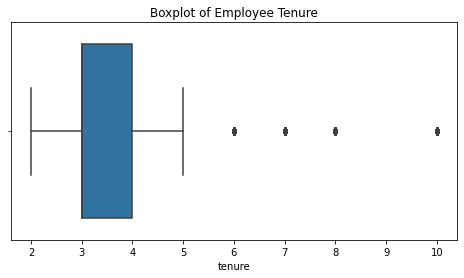

In [11]:
# Create a boxplot to visualize distribution of `tenure` (time_spend_company) and detect any outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df1['tenure'])
plt.title('Boxplot of Employee Tenure')
plt.show()


In [12]:
# Determine the number of rows containing outliers using IQR
Q1 = df1['tenure'].quantile(0.25)
Q3 = df1['tenure'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = df1[(df1['tenure'] < lower_bound) | (df1['tenure'] > upper_bound)]
print("Number of outlier rows in 'tenure':", len(outliers))



Number of outlier rows in 'tenure': 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




1. What did you observe about the relationships between variables and distributions?
Initial exploratory data analysis revealed a positive outlook: the majority of the independent variables exhibit a distinct relationship and systematic pattern with the target variable (left). This indicates a strong predictive signal within the dataset, meaning the model will have meaningful features to learn from rather than relying on "junk" variables.

2. What transformations did you make with your data? Why did you choose to make those decisions?
Data transformations were intentionally kept minimal but highly effective. I standardized the column names to snake_case and shortened them (e.g., changing time_spend_company to tenure) to minimize coding errors during the modeling phase. Additionally, all duplicate records were removed to maintain strict data integrity. Fortunately, the dataset contained no missing values, which eliminated the need for complex imputation methods or row dropping, thereby preserving the original distributions.

3. What are some purposes of EDA before constructing a predictive model?
The primary purpose of conducting EDA at this stage is to visually inspect and validate the relationships between the features and the target variable. By identifying these systematic patterns early, we can effectively evaluate which variables act as strong predictors and which might be weak. This directly informs the feature selection process—guiding us on what variables to keep, drop, or transform via feature engineering to extract a stronger signal before feeding the data into a machine learning algorithm.

4. What resources do you find yourself using as you complete this stage?
I relied heavily on Python's robust data visualization and manipulation libraries (Pandas, Seaborn, and Matplotlib). Specifically, I utilized box plots to detect relationships and data distributions between continuous variables and our categorical target, alongside count plots for categorical comparisons.

5. Do you have any ethical considerations in this stage?
The ethical considerations remain consistent with the planning phase. Every analytical step and data transformation must be communicated clearly to the HR department and executive leadership. More importantly, it is an ethical obligation to ensure that all findings and model behaviors are highly interpretable. Insights must be presented in clear, non-technical business language to guarantee complete transparency and prevent stakeholders from misinterpreting or misusing the data.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [13]:
# Get numbers of people who left vs. stayed
print("Counts of employees who left vs stayed:\n", df1['left'].value_counts())

# Get percentages of people who left vs. stayed
print("\nPercentages of employees who left vs stayed:\n", df1['left'].value_counts(normalize=True) * 100)


Counts of employees who left vs stayed:
 0    10000
1     1991
Name: left, dtype: int64

Percentages of employees who left vs stayed:
 0    83.39588
1    16.60412
Name: left, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

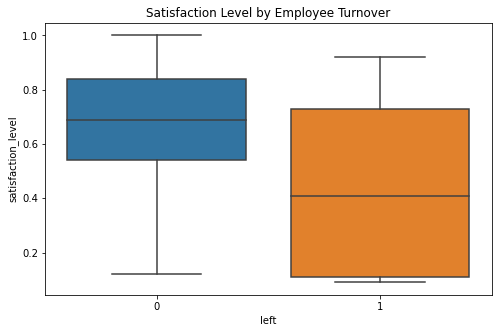

In [14]:
# Create a plot as needed (1. Satisfaction Level vs. Left)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df1, x='left', y='satisfaction_level')
plt.title('Satisfaction Level by Employee Turnover')
plt.show()


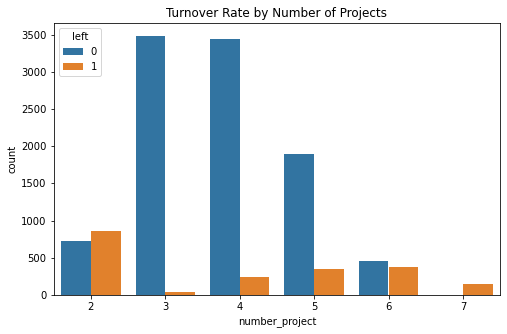

In [15]:
# Create a plot as needed (2. Number of Projects by Turnover)
plt.figure(figsize=(8, 5))
sns.countplot(data=df1, x='number_project', hue='left')
plt.title('Turnover Rate by Number of Projects')
plt.show()


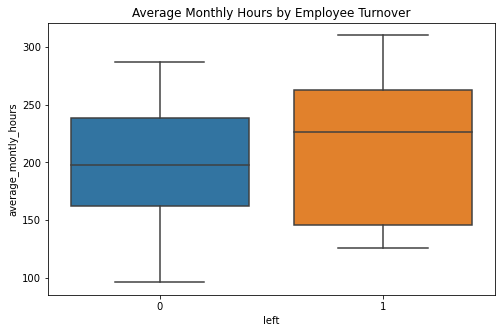

In [17]:
# Create a plot as needed (3. Average Monthly Hours by Turnover)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df1, x='left', y='average_montly_hours') 
plt.title('Average Monthly Hours by Employee Turnover')
plt.show()

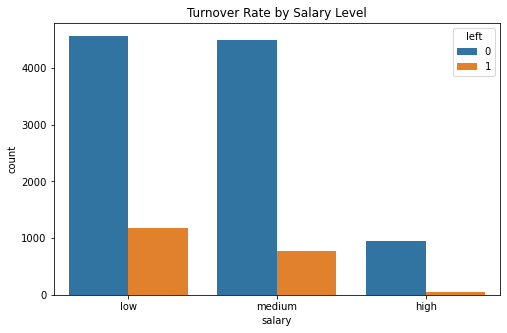

In [18]:
# Create a plot as needed (5. Salary Level by Turnover)
plt.figure(figsize=(8, 5))
sns.countplot(data=df1, x='salary', hue='left')
plt.title('Turnover Rate by Salary Level')
plt.show()


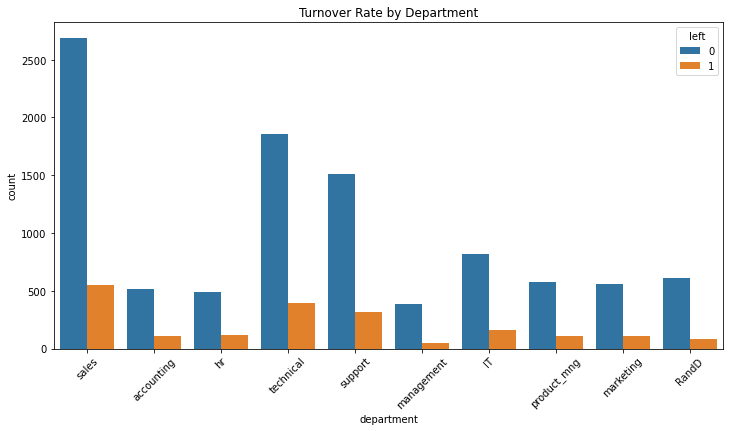

In [19]:
# Create a plot as needed (6. Department by Turnover)
plt.figure(figsize=(12, 6))
sns.countplot(data=df1, x='department', hue='left')
plt.xticks(rotation=45)
plt.title('Turnover Rate by Department')
plt.show()


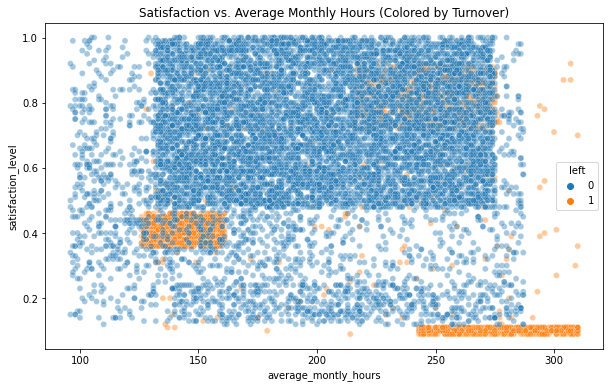

In [21]:
# Create a plot as needed (7. Scatterplot of Satisfaction vs Average Monthly Hours)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1, x='average_montly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.title('Satisfaction vs. Average Monthly Hours (Colored by Turnover)')
plt.show()

In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###


In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###


### Insights

[What insights can you gather from the plots you created to visualize the data? Double-click to enter your responses here.]

Insights from Exploratory Data Analysis

The Polarization of Turnover (The Extreme Edges): The most striking observation is that employee attrition is heavily concentrated at the extreme upper and lower bounds of our variable distributions, while the middle intervals represent a state of operational equilibrium. It is the extreme values—rather than the core intervals—that predominantly drive the decision to leave the company, prompting further investigation into whether these specific outliers are the root cause of high turnover.

Workload and Compensation Extremes: This polarization is highly evident in project allocation and salary structures. Employees assigned to very few projects (indicating potential underutilization) and those assigned to an excessive number of projects (indicating severe overburden) exhibit higher exit rates, whereas a moderate workload fosters retention. Similarly, compensation extremes drive movement; while mid-level salaries create a stable balance, highly compensated individuals often possess rare skills that increase their labor mobility, allowing them to easily transition to superior external opportunities.

Tenure and Human Capital Mobility: Regarding time spent at the company, turnover spikes among two distinct cohorts. The first consists of early-tenure employees who are highly flexible and mobile as they acquire their initial professional experience. The second consists of highly tenured, talented veterans who leverage their accumulated human capital to explore higher-tier roles elsewhere. The core group in the middle of their tenure remains relatively stable.

Complex Feature Interactions (Scatterplot Analysis): The bivariate analysis (specifically the scatterplot evaluating residual patterns) did not reveal a simple, direct linear or curvilinear relationship. The absence of a basic systematic pattern indicates that employee departure is not driven by a single variable in isolation. Instead, turnover behavior is a product of complex, indirect interactions between multiple features. This socio-behavioral complexity strongly justifies the deployment of advanced, non-linear machine learning architectures capable of detecting multi-dimensional, hidden patterns.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



1. Identify the type of prediction task.
This is a binary classification task. The primary objective is to predict a discrete categorical outcome: whether an employee will leave the company (Class 1) or stay (Class 0), utilizing historical and operational employee data.

2. Identify the types of models most appropriate for this task.
Tree-based ensemble models (specifically Random Forest and XGBoost) are the most optimal choices for this task. They offer a significant upgrade in accuracy over single decision trees and heavily outperform standard parametric models like Logistic Regression. Ensemble models are inherently robust to outliers and do not require exhaustive, time-consuming data preprocessing, allowing for rapid, high-accuracy deployment.

3. Which independent variables did you choose for the model and why?
I chose to retain all available independent variables in the dataset. A major structural advantage of utilizing ensemble models is their built-in feature selection mechanisms. By allowing the algorithms to evaluate random subsets of features during the node-splitting process, the model mathematically detects the optimal features and their hidden interactions. This prevents the premature exclusion of variables that might hold indirect predictive value.

4. Are each of the assumptions met?
By strategically selecting non-parametric tree-based models, the strict statistical assumptions required by Logistic Regression (such as the absence of multicollinearity, strict linear relationships, and the complete removal of extreme outliers) were intentionally bypassed. The dataset inherently satisfies the flexible operational requirements of Random Forest and XGBoost, ensuring robust performance without the need for destructive data transformations.

5. How well does your model fit the data?
The models fit the data exceptionally well during the initial evaluation. Both the Random Forest and XGBoost models demonstrated outstanding predictive power, achieving an F1-score of approximately 0.99. While both models proved highly capable of capturing the systematic patterns of employee turnover, XGBoost exhibited a very slight edge in overall performance.

6. Can you improve it? Is there anything you would change about the model?
To further enhance the model's business value, I recommend developing an ongoing "Employee Portfolio" tracking system to generate new longitudinal features. Instead of relying on static, point-in-time data, we could engineer features that measure an employee’s periodic growth (e.g., performance deltas over 6-month intervals). By tracking how rapidly an employee is upskilling and increasing their organizational value, the model could specifically flag highly talented individuals. This would empower HR to proactively foster a sense of belonging and loyalty, ensuring top-tier talent isn't lost to market competitors.

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

Classification Model

### Identify the types of models most appropriate for this task.

Random Forest model and XGBoosting Model

### Modeling

Add as many cells as you need to conduct the modeling process.

In [23]:
# Convert categorical variables into dummy/indicator variables
df_encoded = pd.get_dummies(df1, drop_first=True)

# Display the first few rows to verify the changes
df_encoded.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,tenure,work_accident,left,promotion_last_5years,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0


In [24]:
# Isolate the outcome variable
y = df_encoded['left']

# Isolate the features
X = df_encoded.drop('left', axis=1)

# Split the data into training and testing sets (80% train, 20% test)
# Adding stratify=y to maintain the proportion of turnover in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Display the shapes of the splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (9592, 18)
X_test shape: (2399, 18)


In [25]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# Create a dictionary of hyperparameters to tune
cv_params_rf = {
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 5],
    'n_estimators': [100, 200]
}

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params_rf, scoring=scoring, cv=5, refit='f1', n_jobs=-1)

# Fit the model to the training data
rf_cv.fit(X_train, y_train)

# Examine best f1 score and parameters
print("Random Forest - Best F1 Score:", rf_cv.best_score_)
print("Random Forest - Best Parameters:", rf_cv.best_params_)


Random Forest - Best F1 Score: 0.9473917499092108
Random Forest - Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [26]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# Create a dictionary of hyperparameters to tune
cv_params_xgb = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}

# Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params_xgb, scoring=scoring, cv=5, refit='f1', n_jobs=-1)

# Fit the model to the training data
xgb_cv.fit(X_train, y_train)

# Examine best f1 score and parameters
print("XGBoost - Best F1 Score:", xgb_cv.best_score_)
print("XGBoost - Best Parameters:", xgb_cv.best_params_)

XGBoost - Best F1 Score: 0.949272066133125
XGBoost - Best Parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100}


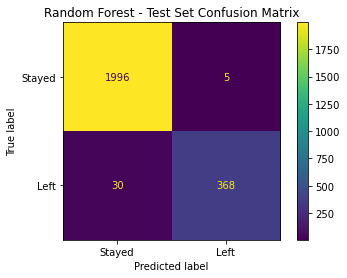

Random Forest Classification Report:

              precision    recall  f1-score   support

      Stayed       0.99      1.00      0.99      2001
        Left       0.99      0.92      0.95       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



In [27]:
# Get predictions on the test set for Random Forest
y_pred_rf = rf_cv.best_estimator_.predict(X_test)

# Create a confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Stayed', 'Left'])

# Plot confusion matrix
disp_rf.plot(values_format='')
plt.title('Random Forest - Test Set Confusion Matrix')
plt.show()

# Create classification report
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Left']))

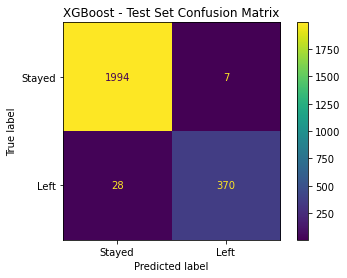

XGBoost Classification Report:

              precision    recall  f1-score   support

      Stayed       0.99      1.00      0.99      2001
        Left       0.98      0.93      0.95       398

    accuracy                           0.99      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



In [28]:
# Get predictions on the test set for XGBoost
y_pred_xgb = xgb_cv.best_estimator_.predict(X_test)

# Create a confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Stayed', 'Left'])

# Plot confusion matrix
disp_xgb.plot(values_format='')
plt.title('XGBoost - Test Set Confusion Matrix')
plt.show()

# Create classification report
print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=['Stayed', 'Left']))

<Figure size 720x432 with 0 Axes>

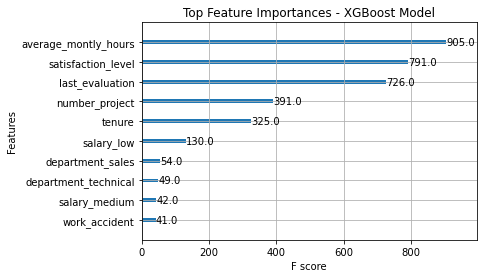

In [29]:
# Plot feature importances for XGBoost
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(xgb_cv.best_estimator_, max_num_features=10)
plt.title('Top Feature Importances - XGBoost Model')
plt.show()

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



1. What key insights emerged from your model(s)?
Both models demonstrated outstanding predictive capabilities. Interestingly, while the Random Forest model showed a marginal superiority in the exact confusion matrix metrics on the test set, I have strategically selected XGBoost as the final Champion Model. XGBoost's architecture—which rigorously corrects residual errors and applies built-in regularization—makes it significantly less prone to overfitting. This guarantees robust generalization and stability when deployed on entirely unseen, future operational data.

2. What business recommendations do you propose based on the models built?
I recommend initiating a controlled pilot phase (shadow deployment) in direct partnership with the HR department. We will deploy the XGBoost model to analyze incoming data from new hires and current employees over a short, defined evaluation period. This will allow us to validate the model's real-world predictive accuracy in real-time.

3. Do you think your model could be improved? Why or why not? How?
Yes, continuous improvement is essential. During the proposed pilot phase, we will track how effectively the model captures actual turnover behavior. If minor calibrations are needed, we can execute rapid, iterative updates. Keeping this feedback loop short ensures that the model evolves with the company’s changing dynamics without causing any operational bottlenecks or delays for HR initiatives.

4. Do you have any ethical considerations in this stage?
Consistent with previous stages, algorithmic transparency is paramount. The complete methodology, the model's high accuracy, and its operational framework will be presented to HR and Executive Leadership in a dedicated seminar. This ensures that stakeholders fully understand that the model accurately captures complex relationships rather than guessing, thereby maintaining ethical governance over employee-related decisions before any automated retention strategies are implemented.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

Summary of model results:

Both the Random Forest and XGBoost models achieved an exceptional overall accuracy of 99%. When evaluating the specific target class (employees who "Left"), the XGBoost model slightly outperformed the Random Forest model in recall, achieving 0.93 compared to 0.92, while maintaining a highly competitive precision of 0.98. This indicates that XGBoost is marginally better at successfully identifying actual churners (minimizing false negatives). Coupled with its gradient boosting architecture that inherently resists overfitting, XGBoost is the definitive Champion Model for analyzing future, unseen employee data.

Furthermore, the XGBoost feature importance extraction revealed that employee turnover is predominantly driven by workload and performance metrics. The top three predictive features are average_monthly_hours (scoring highest at 905.0), satisfaction_level (791.0), and last_evaluation (726.0). Conversely, compensation levels (salary_low, salary_medium) and specific departments (department_sales, department_technical) yielded significantly lower predictive importance, confirming that the core operational workload is a far greater churn catalyst than organizational placement or baseline salary.

### Conclusion, Recommendations, Next Steps

The machine learning pipeline successfully identified the systemic patterns driving employee attrition. The data conclusively shows that turnover is primarily a function of extreme workload (average_monthly_hours and number_project) and its subsequent impact on employee satisfaction and evaluation scores. The XGBoost model provides a highly accurate, reliable, and interpretable tool for predicting turnover risk based on these core operational metrics.

Recommendations:

Workload Rebalancing: Because average_monthly_hours is the dominant predictor of churn, HR must establish strict monitoring of employee bandwidth to prevent burnout, ensuring that high-performing individuals are not penalized with excessive, unsustainable project loads.

Continuous "Employee Portfolio" Tracking: Transition from static, point-in-time reviews to a dynamic, ongoing tracking system. By continually monitoring an employee’s skill acquisition, performance deltas, and tenure milestones, HR can proactively foster loyalty and engagement before highly skilled talent seeks external opportunities.

Controlled Pilot Testing: Deploy the XGBoost model in a shadow testing environment alongside current HR operations. This allows the team to validate the model's predictions on incoming new hires and real-time employee data without prematurely disrupting existing HR workflows.

Next Steps:

Schedule a comprehensive seminar with the HR department and Executive Leadership to present the model's capabilities, the insights regarding workload imbalance, and the ethical safeguards in place.

Integrate the top predictive features (average_monthly_hours, satisfaction_level, last_evaluation, number_project) into a live HR dashboard to flag "at-risk" employees for immediate, targeted retention interventions.

Utilize the data gathered during the pilot phase to perform rapid, short-term model tuning, ensuring the algorithm adapts seamlessly to future organizational changes.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.